<a href="https://colab.research.google.com/github/nayakamhrudaya/GenAI/blob/main/Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


                             user                       user_id  \
0  Amazon CustomerAmazon Customer  AH5M24Z73ZHQGN77WA3JT3Q7TEBQ   
1                       Wyeventer  AFI7ALURI5CPDT4V7CUXZXLNFDVA   
2                               A  AENH6LSB6BM7XLPEYUL43WBOD6JA   
3                  Aylene W. Barr  AHFAAT5CJ6IIGIURHFBICP44ZHVA   
4                          Ivette  AG4UMTWF2QN3BRDCSNVXTGZTPCAA   

                                            title  \
0             NUWAVE, GRILL IS PRETTY GOOD SO FAR   
1                                    Game changer   
2                        More Than Meets My Needs   
3  Great machine and incredible customer support!   
4                                         Love it   

                                          review_url          extension  \
0  https://www.amazon.com/gp/customer-reviews/R29...  Verified Purchase   
1  https://www.amazon.com/gp/customer-reviews/R1F...  Verified Purchase   
2  https://www.amazon.com/gp/customer-reviews/R2V... 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


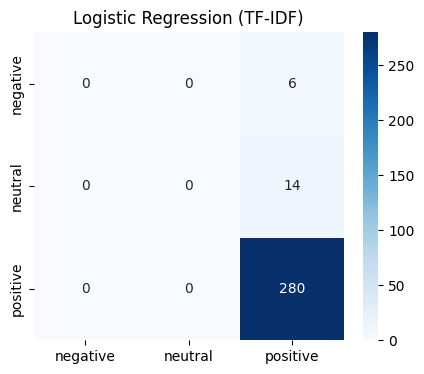


Naive Bayes (BoW)
Accuracy: 0.9133333333333333

Classification Report:
               precision    recall  f1-score   support

    negative       1.00      0.17      0.29         6
     neutral       0.29      0.43      0.34        14
    positive       0.96      0.95      0.96       280

    accuracy                           0.91       300
   macro avg       0.75      0.52      0.53       300
weighted avg       0.93      0.91      0.91       300



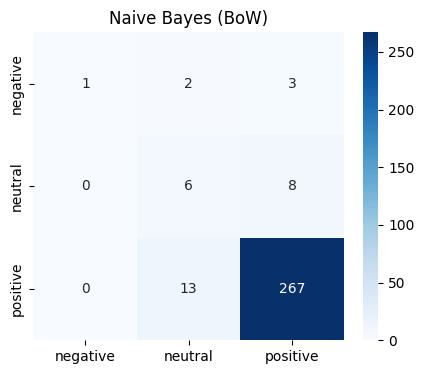

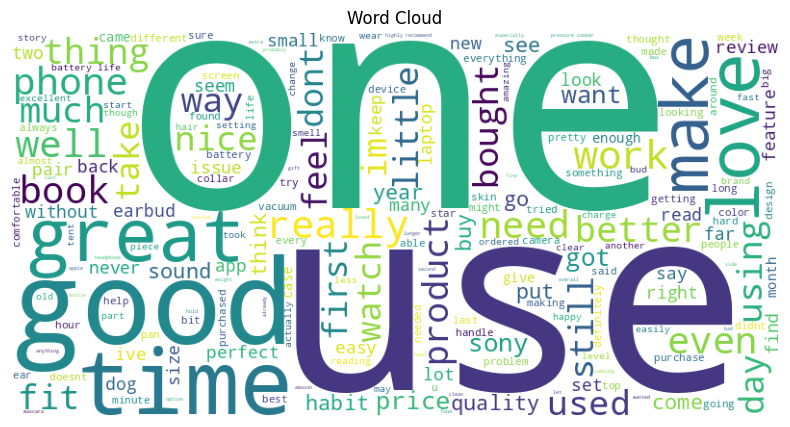

In [ ]:
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ===============================
# DOWNLOAD NLTK
# ===============================
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# ===============================
# LOAD DATASET (WORKING URL)
# ===============================
url = "https://huggingface.co/datasets/XANJEEV/amazon-product-reviews/resolve/main/dataset/dataset.csv"
df = pd.read_csv(url)

print(df.head())
print(df.columns)

# ===============================
# FIX COLUMNS (based on dataset)
# ===============================
df = df[['review', 'rating']]
df.columns = ['reviewText', 'rating']

# Convert 'rating' column to numeric, coercing errors to NaN
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
# Drop rows where 'rating' could not be converted (i.e., were non-numeric)
df.dropna(subset=['rating'], inplace=True)
# Convert 'rating' to integer type after dropping NaNs
df['rating'] = df['rating'].astype(int)

# ===============================
# CREATE SENTIMENT LABELS
# ===============================
def get_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['rating'].apply(get_sentiment)

# ===============================
# TEXT PREPROCESSING
# ===============================
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(f"[{string.punctuation}]", "", text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

df['clean_text'] = df['reviewText'].apply(preprocess)

# ===============================
# TRAIN TEST SPLIT
# ===============================
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# FEATURE EXTRACTION
# ===============================
bow = CountVectorizer(max_features=3000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

tfidf = TfidfVectorizer(max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# ===============================
# MODEL BUILDING
# ===============================
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_tfidf, y_train)

nb = MultinomialNB()
nb.fit(X_train_bow, y_train)

# ===============================
# EVALUATION
# ===============================
def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("="*40)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_,
                yticklabels=model.classes_)
    plt.title(name)
    plt.show()

evaluate(lr, X_test_tfidf, y_test, "Logistic Regression (TF-IDF)")
evaluate(nb, X_test_bow, y_test, "Naive Bayes (BoW)")

# ===============================
# WORD CLOUD
# ===============================
text = " ".join(df['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud")
plt.show()